# 01 — Auditoría de datasets (Semana 2)

Vista reproducible y comprensible de la **auditoría de datasets de hongos** (Semana 2, Fase 2: auditoría y curaduría).

* La lógica principal vive en `scripts/data/` (`acquire_datasets.py`, `audit_datasets.py`, `adapters.py`, `audit_core.py`, `inventory.py`).
  Este notebook **no la duplica**: lee los resultados versionados de `reports/audit/` y vuelve a ejecutar en vivo, con el código de
  los scripts, las fuentes pequeñas (DF20, SiB Colombia) para comprobar que los números coinciden.
* **No se modificó ningún dato**: no hay eliminación, imputación, deduplicación, particiones ni entrenamiento (todo eso es de la Semana 3 o posteriores).
* Etiquetas de evidencia usadas: `SOURCE_REPORTED` (lo declara la fuente), `LOCAL_VERIFIED` (calculado por nosotros sobre archivos locales),
  `DERIVED` (deducido en memoria, p. ej. género a partir del nombre científico) y `NOT_VERIFIED` (no se pudo comprobar).

**Requisitos:** `pip install -r requirements.txt`, y haber ejecutado `python scripts/data/acquire_datasets.py` (datos en `data/raw/`, no versionados).

In [1]:
import sys, json
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

# raíz del repositorio (el notebook vive en notebooks/)
ROOT = Path.cwd().resolve()
if not (ROOT / "scripts").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts" / "data"))
AUDIT = ROOT / "reports" / "audit"
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40); pd.set_option("display.max_colwidth", 60)
print("Raíz del repositorio:", ROOT.name, "| resultados:", len(list(AUDIT.glob('*.csv'))), "CSV")

Raíz del repositorio: edge-ai-virtus | resultados: 8 CSV


## 1. Datasets auditados

Inventario (`data/manifests/dataset_inventory.csv`): una fila por fuente, con su estado de acceso y la justificación.

In [2]:
inv = pd.read_csv(ROOT / "data" / "manifests" / "dataset_inventory.csv")
inv[["dataset_id", "status", "local_data_available", "visual_suitability"]]

,dataset_id,status,local_data_available,visual_suitability
0,fungitastic,METADATA_AVAILABLE,"metadatos completos (CSV, sin imágenes)",SUITABLE_CANDIDATE (fuera del contexto geográfico colomb...
1,fungitastic_aux_modalities,ACCESS_PROBLEM,ninguno,NOT_VERIFIED
2,df20,METADATA_AVAILABLE,"metadatos completos (CSV, sin imágenes)",SUITABLE_CANDIDATE (contexto europeo; solapado con Fungi...
3,mind_funga_v2,REQUIRES_REVIEW,índice de archivos + nombres de carpeta (sin imágenes),REQUIRES_REVIEW (contexto neotropical relevante; sin agr...
4,inaturalist_api,REMOTE_QUERYABLE,instantáneas JSON de consultas + muestra de 200 observac...,SUITABLE_CANDIDATE (para prueba colombiana; requiere fil...
5,inaturalist_open_data,REMOTE_QUERYABLE,taxonomía completa (taxa.csv.gz) + fragmentos de esquema,SUITABLE_CANDIDATE (fuente principal de fotos abiertas; ...
6,sib_colombia_portal,DOCUMENTED_ONLY,ninguno (ver recursos sib_*),NOT_VERIFIED
7,sib_macrohongosmitu,AVAILABLE_LOCAL,registros completos (DwC-A); sin imágenes,NOT_SUITABLE (sin imágenes en los datos)
8,sib_macrohongos_jbb_2023_1,AVAILABLE_LOCAL,registros completos (DwC-A); sin imágenes,NOT_SUITABLE (sin imágenes en los datos)
9,sib_hongos_col2023,AVAILABLE_LOCAL,registros completos (DwC-A); sin imágenes,NOT_SUITABLE (sin imágenes en los datos)


In [3]:
inv[["dataset_id", "status", "status_reason"]].assign(status_reason=lambda d: d.status_reason.str.slice(0, 230))

,dataset_id,status,status_reason
0,fungitastic,METADATA_AVAILABLE,Se descargó y auditó localmente el metadata.zip oficial ...
1,fungitastic_aux_modalities,ACCESS_PROBLEM,climatic.zip responde HTTP 403 en el servidor oficial (s...
2,df20,METADATA_AVAILABLE,Se descargó y auditó localmente DF20-metadata.zip (train...
3,mind_funga_v2,REQUIRES_REVIEW,"Índice completo de archivos (18023 JPG, con SHA-256 publ..."
4,inaturalist_api,REMOTE_QUERYABLE,"Se ejecutaron decenas de consultas pequeñas (conteos, li..."
5,inaturalist_open_data,REMOTE_QUERYABLE,Se descargó solo taxa.csv.gz (40 MB) y fragmentos inicia...
6,sib_colombia_portal,DOCUMENTED_ONLY,"Portal informativo (registros biológicos, listas, fichas..."
7,sib_macrohongosmitu,AVAILABLE_LOCAL,Se descargó y auditó el DwC-A completo (60 registros). E...
8,sib_macrohongos_jbb_2023_1,AVAILABLE_LOCAL,Se descargó y auditó el DwC-A completo (184 registros). ...
9,sib_hongos_col2023,AVAILABLE_LOCAL,Se descargó y auditó el DwC-A completo (1462 registros)....


## 2. Tamaño: imágenes vs. observaciones

Nunca se trata cada imagen como una observación independiente. Cifras `LOCAL_VERIFIED` (o `DERIVED`/muestra donde `is_sample` es verdadero); son *filas de metadatos*, no archivos de imagen comprobados.

In [4]:
size = pd.read_csv(AUDIT / "size_summary.csv")
main = size[~size.table.str.contains(r"^(?:full|mini|fewshot)/")]   # ocultamos los CSV individuales de FungiTastic (ver el CSV completo)
main[["dataset_id", "table", "is_sample", "n_images", "n_observations", "n_species", "n_genera",
      "images_per_observation_mean", "images_per_observation_median", "images_per_observation_max"]]

,dataset_id,table,is_sample,n_images,n_observations,n_species,n_genera,images_per_observation_mean,images_per_observation_median,images_per_observation_max
13,fungitastic,full_union,False,633114.0,346459.0,4418.0,1406.0,1.827,1.0,24.0
14,fungitastic,mini_union,False,67634.0,36215.0,210.0,6.0,1.868,1.0,16.0
15,fungitastic,fewshot_union,False,12015.0,6391.0,2413.0,1014.0,1.880,1.0,30.0
16,mind_funga_v2,files_v2,False,18023.0,NaN,346.0,240.0,NaN,NaN,NaN
17,inaturalist_open_data,observations_head_fragment,True,NaN,43784.0,NaN,NaN,NaN,NaN,NaN
18,inaturalist_open_data,photos_head_fragment,True,70440.0,48607.0,NaN,NaN,1.455,1.0,45.0
19,inaturalist_api,random_sample200_research_photos,True,NaN,200.0,96.0,72.0,NaN,NaN,NaN
20,sib_macrohongosmitu,occurrence,False,0.0,60.0,25.0,27.0,NaN,NaN,NaN
21,sib_macrohongos_jbb_2023_1,occurrence,False,0.0,184.0,56.0,44.0,NaN,NaN,NaN
22,sib_hongos_col2023,occurrence,False,0.0,1462.0,24.0,245.0,NaN,NaN,NaN


## 3. Metadatos disponibles

Porcentaje de ausentes por tipo de campo en la tabla principal de cada dataset (`NA` = el campo no existe en la fuente).

In [5]:
mm = pd.read_csv(AUDIT / "metadata_matrix.csv")
mm

,dataset_id,primary_table,species_pct_missing,genus_pct_missing,family_pct_missing,observation_id_pct_missing,image_id_pct_missing,latitude_pct_missing,longitude_pct_missing,date_pct_missing,country_pct_missing,substrate_pct_missing,habitat_pct_missing,license_pct_missing,author_pct_missing
0,fungitastic,full_union,0.000,0.000,0.900,0.0,NaN,0.001,0.001,0.000,0.000,4.847,0.001,NaN,NaN
1,fungitastic_aux_modalities,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,df20,train+public_test,0.011,0.000,0.890,0.0,0.0,0.000,0.000,0.006,0.408,0.516,0.369,NaN,0.000
3,mind_funga_v2,files_v2,18.493,0.000,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,inaturalist_api,random_sample200_research_photos,2.000,0.000,NaN,0.0,NaN,0.000,0.000,0.000,NaN,NaN,NaN,0.000,0.000
5,inaturalist_open_data,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,sib_colombia_portal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,sib_macrohongosmitu,occurrence,55.000,1.667,1.667,0.0,NaN,100.000,100.000,0.000,0.000,NaN,100.000,100.000,0.000
8,sib_macrohongos_jbb_2023_1,occurrence,0.000,46.739,42.391,0.0,NaN,0.000,0.000,0.000,0.000,NaN,100.000,100.000,0.000
9,sib_hongos_col2023,occurrence,97.743,16.211,11.970,0.0,NaN,11.696,65.116,0.000,0.000,NaN,NaN,100.000,0.000


## 4. Valores faltantes

Conteo de nulos, cadenas vacías y marcadores especiales (`unknown`, `NA`, …). Ejemplo: campos clave de DF20 y FungiTastic.

In [6]:
miss = pd.read_csv(AUDIT / "missing_values.csv")
sel = miss[(miss.column_present) & (miss.table.isin(["full_union", "train+public_test"])) &
           (miss.role.isin(["species", "genus", "family", "date", "latitude", "longitude", "substrate", "habitat", "region"]))]
sel.pivot_table(index="role", columns=["dataset_id"], values="pct_missing").round(3)

dataset_id,df20,fungitastic
role,,
date,0.006,0.000
family,0.890,0.900
genus,0.000,0.000
habitat,0.369,0.001
latitude,0.000,0.001
longitude,0.000,0.001
region,0.408,0.356
species,0.011,0.000
substrate,0.516,4.847


In [7]:
# valores implausibles o con formato no estándar (no son ausentes): coordenadas fuera de rango, fechas no ISO...
bad = miss[(miss.n_suspicious.fillna(0) > 0) | (miss.n_nonstandard_format.fillna(0) > 0)]
bad[["dataset_id", "table", "role", "n_rows", "n_suspicious", "n_nonstandard_format", "suspicious_rule"]].head(25)

,dataset_id,table,role,n_rows,n_suspicious,n_nonstandard_format,suspicious_rule
10,fungitastic,full/Train,latitude,433702,6.0,0.0,"lat outside [-90,90], unparsable, or (lat,lon)==(0,0)"
30,fungitastic,full_union,latitude,633114,6.0,0.0,"lat outside [-90,90], unparsable, or (lat,lon)==(0,0)"
189,sib_macrohongos_jbb_2023_1,occurrence,date,184,0.0,184.0,"date unparsable or year outside [1800, current]; non-sta..."
209,sib_hongos_col2023,occurrence,date,1462,0.0,1460.0,"date unparsable or year outside [1800, current]; non-sta..."
210,sib_hongos_col2023,occurrence,latitude,1462,798.0,0.0,"lat outside [-90,90], unparsable, or (lat,lon)==(0,0)"
211,sib_hongos_col2023,occurrence,longitude,1462,114.0,0.0,"lon outside [-180,180] or unparsable"
229,gbif,colombia_stillimage_sample900,date,900,10.0,0.0,"date unparsable or year outside [1800, current]; non-sta..."
250,mushroom_observer,fungi_all_observations,latitude,608302,88.0,0.0,"lat outside [-90,90], unparsable, or (lat,lon)==(0,0)"
330,df20,train+public_test,latitude,295938,9.0,0.0,"lat outside [-90,90], unparsable, or (lat,lon)==(0,0)"


## 5. Duplicados

* Duplicados **confirmados** internos (filas idénticas, IDs repetidos, URLs, nombres de archivo): `duplicates.csv`.
* SHA-256 de imágenes: **no verificado** (no se descargaron imágenes). En MIND.Funga se usan los SHA-256 *publicados por la fuente* (`SOURCE_REPORTED`).
* Solapamiento entre datasets: `overlaps.csv` (intersecciones de identificadores, sin combinar datos).

In [8]:
dup = pd.read_csv(AUDIT / "duplicates.csv")
dup.drop(columns=["dataset_specific_checks"])[["dataset_id", "table", "n_rows", "is_sample", "n_exact_duplicate_rows",
    "n_rows_with_repeated_image_id", "n_rows_with_repeated_image_file", "n_observation_ids_with_multiple_rows",
    "n_observations_with_conflicting_species"]]

,dataset_id,table,n_rows,is_sample,n_exact_duplicate_rows,n_rows_with_repeated_image_id,n_rows_with_repeated_image_file,n_observation_ids_with_multiple_rows,n_observations_with_conflicting_species
0,fungitastic,full/Train,433702,False,0,NaN,0.0,109998.0,0.0
1,fungitastic,full_union,633114,False,0,NaN,0.0,163952.0,0.0
2,fungitastic,mini_union,67634,False,0,NaN,0.0,17980.0,0.0
3,fungitastic,fewshot_union,12015,False,0,NaN,0.0,3105.0,0.0
4,mind_funga_v2,files_v2,18023,False,0,0.0,42.0,NaN,NaN
5,inaturalist_open_data,observations_head_fragment,43784,True,0,NaN,NaN,0.0,NaN
6,inaturalist_open_data,photos_head_fragment,70737,True,0,576.0,NaN,11833.0,NaN
7,inaturalist_api,random_sample200_research_photos,200,True,0,NaN,NaN,0.0,0.0
8,sib_macrohongosmitu,occurrence,60,False,0,NaN,0.0,0.0,0.0
9,sib_macrohongos_jbb_2023_1,occurrence,184,False,0,NaN,0.0,0.0,0.0


In [9]:
ov = pd.read_csv(AUDIT / "overlaps.csv")
ov[ov.scope.str.startswith(("between", "within DF20", "aggregator"))][["scope", "set_a", "set_b", "n_a", "n_b", "n_intersection"]]

,scope,set_a,set_b,n_a,n_b,n_intersection
10,aggregator overlap (GBIF),gbif: Fungi+StillImage+country=CO,gbif dataset 'iNaturalist Research-grade Observations',21638,9678,9678
11,aggregator overlap (GBIF),gbif: Fungi+StillImage+country=CO,gbif dataset 'Mushroom Observer',21638,1828,1828
12,between datasets (DF20 vs FungiTastic),df20:train,fungitastic:Train,166415,246884,160297
13,between datasets (DF20 vs FungiTastic),df20:train,fungitastic:ClosedSet-Val,166415,45613,0
14,between datasets (DF20 vs FungiTastic),df20:train,fungitastic:ClosedSet-Test,166415,48378,0
15,between datasets (DF20 vs FungiTastic),df20:train,fungitastic:DNA-Test,166415,2041,357
16,between datasets (DF20 vs FungiTastic),df20:train,fungitastic:full_union,166415,346459,160654
17,between datasets (DF20 vs FungiTastic),df20:public_test,fungitastic:Train,27814,246884,26808
18,between datasets (DF20 vs FungiTastic),df20:public_test,fungitastic:ClosedSet-Val,27814,45613,0
19,between datasets (DF20 vs FungiTastic),df20:public_test,fungitastic:ClosedSet-Test,27814,48378,0


## 6. Distribución taxonómica y cola larga

Desbalance por especie (imágenes y observaciones): mínimo, mediana, máximo, relación máx/mín y número de clases con pocas muestras.

In [10]:
imb = pd.read_csv(AUDIT / "imbalance_summary.csv")
imb[(imb.level == "species") & (imb.unit.isin(["images", "observations"])) & (imb.n_classes > 20)][
    ["dataset_id", "table", "unit", "n_classes", "min", "median", "max", "ratio_max_min", "n_classes_lt5", "n_classes_lt10",
     "pct_samples_in_top10pct_classes", "gini"]]

,dataset_id,table,unit,n_classes,min,median,max,ratio_max_min,n_classes_lt5,n_classes_lt10,pct_samples_in_top10pct_classes,gini
0,fungitastic,full/Train,images,2786,6,52.0,2789,464.8,0,98,52.22,0.6655
1,fungitastic,full/Train,observations,2786,5,27.0,1592,318.4,0,659,53.69,0.6858
6,fungitastic,full_union,images,4418,1,30.0,4073,4073.0,642,1257,63.68,0.7642
7,fungitastic,full_union,observations,4418,1,13.0,2328,2328.0,1476,1964,66.71,0.7920
12,fungitastic,mini_union,images,210,9,169.0,2505,278.3,0,1,42.60,0.5810
13,fungitastic,mini_union,observations,210,5,93.0,1547,309.4,0,7,43.28,0.5898
18,fungitastic,fewshot_union,images,2413,1,3.0,50,50.0,1478,2109,33.27,0.4624
19,fungitastic,fewshot_union,observations,2413,1,2.0,24,24.0,2075,2375,29.10,0.3886
24,mind_funga_v2,files_v2,images,346,1,23.0,714,714.0,34,75,42.20,0.5621
27,inaturalist_api,random_sample200_research_photos,observations,96,1,1.0,25,25.0,90,94,41.84,0.4307


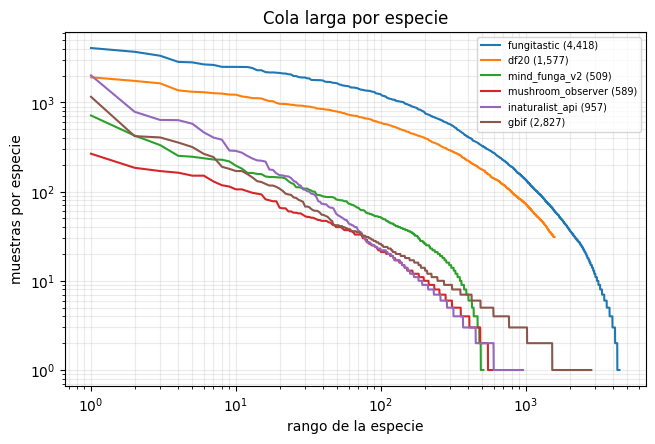

In [11]:
cd = pd.read_csv(AUDIT / "class_distribution.csv")
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for ds, tb, lv, col in [("fungitastic", "full_union", "species", "n_images"), ("df20", "train+public_test", "species", "n_images"),
                        ("mind_funga_v2", "files_v2", "label_folder", "n_images"), ("mushroom_observer", "fungi_colombia_images", "species", "n_images"),
                        ("inaturalist_api", "species_counts_research_grade", "species", "n_observations"),
                        ("gbif", "colombia_stillimage_records", "species", "n_observations")]:
    v = np.sort(cd[(cd.dataset_id == ds) & (cd.table == tb) & (cd.level == lv)][col].dropna().values)[::-1]
    if len(v):
        ax.plot(np.arange(1, len(v) + 1), v, label=f"{ds} ({len(v):,})")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("rango de la especie"); ax.set_ylabel("muestras por especie")
ax.set_title("Cola larga por especie"); ax.grid(alpha=.25, which="both"); ax.legend(fontsize=7); plt.show()

## 7. Comprobación en vivo con el código de `scripts/data/`

Se reejecutan los adaptadores de DF20 y de los tres recursos SiB Colombia sobre los datos locales y se comparan con los CSV versionados.

In [12]:
import adapters as A, audit_core as C
live = []
for res in [A.audit_df20()] + [A.audit_sib_resource(d) for d in ["sib_macrohongosmitu", "sib_macrohongos_jbb_2023_1", "sib_hongos_col2023"]]:
    for t in res.tables:
        if t.main:
            live.append(C.size_summary(t))
live = pd.DataFrame(live)
chk = live.merge(size, on=["dataset_id", "table"], suffixes=("_vivo", "_csv"))
chk["coincide"] = (chk.n_rows_vivo == chk.n_rows_csv) & (chk.n_observations_vivo.fillna(-1) == chk.n_observations_csv.fillna(-1))
chk[["dataset_id", "table", "n_rows_vivo", "n_rows_csv", "n_observations_vivo", "n_observations_csv", "coincide"]]

,dataset_id,table,n_rows_vivo,n_rows_csv,n_observations_vivo,n_observations_csv,coincide
0,df20,train+public_test,295938,295938,177170,177170.0,True
1,sib_macrohongosmitu,occurrence,60,60,60,60.0,True
2,sib_macrohongos_jbb_2023_1,occurrence,184,184,184,184.0,True
3,sib_hongos_col2023,occurrence,1462,1462,1462,1462.0,True


## 8. Principales problemas encontrados

Resumen generado a partir de los resultados (el detalle y la interpretación están en `reports/week_02_dataset_audit.md`).

In [13]:
facts = json.loads((AUDIT / "audit_facts.json").read_text(encoding="utf-8"))
def inter(a, b):
    r = ov[(ov.set_a == a) & (ov.set_b == b)].iloc[0]
    return int(r.n_intersection), int(r.n_a)
n, tot = inter("df20:union", "fungitastic:full_union")
print(f"• DF20 ∩ FungiTastic (observaciones compartidas): {n:,} de {tot:,} observaciones de DF20")
n, tot = inter("df20:train", "df20:public_test")
print(f"• DF20: observaciones con imágenes tanto en train como en test: {n:,}")
sha = json.loads(dup[dup.dataset_id == "mind_funga_v2"].dataset_specific_checks.iloc[0])
print("• MIND.Funga: archivos en grupos con SHA-256 idéntico (reportado por la fuente):", int(sha["sha256_source_reported_files_in_duplicate_groups"]))
sib = ["sib_macrohongosmitu", "sib_macrohongos_jbb_2023_1", "sib_hongos_col2023"]
print("• SiB Colombia (3 recursos): registros con fotografías enlazadas:", sum(facts[d]["facts"]["n_associatedMedia_nonempty"] for d in sib))
print("• Licencias de FungiTastic: inconsistentes entre fuentes (ver inventario, columna license_notes).")

• DF20 ∩ FungiTastic (observaciones compartidas): 170,996 de 177,170 observaciones de DF20
• DF20: observaciones con imágenes tanto en train como en test: 17,059
• MIND.Funga: archivos en grupos con SHA-256 idéntico (reportado por la fuente): 3321
• SiB Colombia (3 recursos): registros con fotografías enlazadas: 0
• Licencias de FungiTastic: inconsistentes entre fuentes (ver inventario, columna license_notes).
